In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as so
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (r2_score, mean_squared_error, accuracy_score, f1_score, classification_report,
                            confusion_matrix, roc_auc_score, RocCurveDisplay)
from google.colab import files


uploaded = files.upload()
D = pd.read_csv('diabetes_risk_dataset.csv')

# Cleaning up Variables Dataset (Converting Categorical data to Numerical data)
D['gender'] = D['gender'].map({'Female': 0, 'Male': 1})
D['physical_activity_level'] = D['physical_activity_level'].map({'Low': 0, 'Moderate': 1, 'High': 2})
D['family_history_diabetes'] = D['family_history_diabetes'].map({'No' : 0, 'Yes' : 1})
D['diabetes_risk_category'] = D['diabetes_risk_category'].map({'Low Risk': 0, 'High Risk': 1, 'Prediabetes': 2})

Saving diabetes_risk_dataset.csv to diabetes_risk_dataset.csv


In [ ]:
# Separating Explanatory and Response Variables
Y = D["diabetes_risk_category"]
X = D.drop(["diabetes_risk_score", "diabetes_risk_category", "Patient_ID"], axis=1)
# Making the train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=41)


In [ ]:
D

,Patient_ID,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,1,77,0,33.8,154,93,12.1,5.2,242,194,0,2169,78.4,8.1,4,0,101.1,52.3,2
1,2,54,1,19.2,123,94,4.6,5.4,212,76,2,1881,16.5,6.6,3,0,60.0,3.7,0
2,3,25,1,33.7,141,150,10.8,6.9,247,221,0,2811,147.9,6.7,10,1,114.7,87.3,1
3,4,23,0,32.8,140,145,11.6,6.8,195,193,0,2826,98.3,4.4,9,1,96.6,76.1,1
4,5,70,1,33.7,165,90,18.3,5.6,217,170,1,2610,65.8,9.1,5,1,107.4,47.7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,5996,58,1,21.8,158,89,6.3,5.3,198,132,2,1995,44.1,7.6,7,0,82.7,0.0,0
5996,5997,73,1,47.3,193,109,33.7,6.1,250,209,0,3401,61.4,5.3,10,1,150.0,100.0,1
5997,5998,35,1,31.0,139,90,15.1,5.3,190,164,1,3022,86.7,6.8,3,1,102.7,22.3,0
5998,5999,58,1,26.2,136,88,6.3,5.5,223,126,2,2311,28.2,8.4,5,0,90.6,3.9,0


In [ ]:
# Logistic Regression
# TODO: scale features
lr = LogisticRegression(max_iter=10000, random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.3f}")
print(f"F1 (macro): {f1_score(y_test, lr_preds, average='macro'):.3f}")
print(classification_report(y_test, lr_preds))

=== Logistic Regression ===
Accuracy:  0.883
F1 (macro): 0.854
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       506
           1       0.91      0.93      0.92       447
           2       0.73      0.69      0.71       247

    accuracy                           0.88      1200
   macro avg       0.86      0.85      0.85      1200
weighted avg       0.88      0.88      0.88      1200



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Random Forest ===
Accuracy:  0.918
F1 (macro): 0.900
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       506
           1       0.96      0.94      0.95       447
           2       0.79      0.81      0.80       247

    accuracy                           0.92      1200
   macro avg       0.90      0.90      0.90      1200
weighted avg       0.92      0.92      0.92      1200



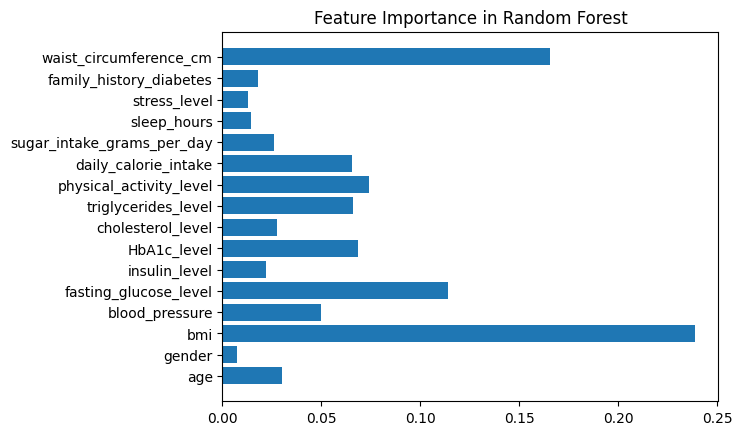

In [ ]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=41)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# print("R²:", r2_score(y_test, y_pred))
# print("RMSE:", mean_squared_error(y_test, y_pred))
print("=== Random Forest ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"F1 (macro): {f1_score(y_test, y_pred, average='macro'):.3f}")
print(classification_report(y_test, y_pred))

importances = rf_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance in Random Forest")
plt.show()

In [ ]:
# Testing the Model!

# 1. The logistic regression model

